<a href="https://colab.research.google.com/github/Denizorhanekim/Betriebssytseme-Uebung2/blob/main/group4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Group 4. Framingham Heart Study**

# Contribution Declaration
- Introduction, context, data generation - Youngchae Lee
- Data exploration, code, visualization - Deniz Orhan
- Summary and discussion - Both

# Short Summary
What is the dataset?  
- The dataset is Framingham Heart Study, a foundational cohort research project that tracked thousands of participants across multiple generations to identify long-term risk factors for cardiovascular disease.

Type of data (e.g., EHR, genomics, survey, time series)
- This is an observational, longitudinal time-series (repeated-measures cohort) dataset consisting of patient records collected sequentially across multiple examination cycles over several decades.
- While the original study is a longitudinal time-series cohort, the specific dataset utilized in our practical analysis is a static, cross-sectional (single-wave) subset representing 4,240 patient records captured at the baseline examination cycle.

Main variables / outcomes
- Predictors (Features): **Demographic metrics** (age, male), **behavioral characteristics** (currentSmoker, cigsPerDay), and time-varying **clinical indicators** (totChol, sysBP, diaBP, BMI, heartRate, glucose) measured repeatedly at each exam wave.
- Primary Outcome (Target Variable): The longitudinal development or incidence of Coronary Heart Disease (CHD) or cardiovascular events documented throughout the multi-decade follow-up period.

One key strength
- The primary strength of this dataset is its exceptional longitudinal and temporal depth, which allows researchers to analyze how changes in clinical metrics over time (time-series trends) directly impact long-term cardiovascular outcomes.

One key limitation
- A significant limitation is the presence of time-dependent confounding and missing data caused by patient attrition, skipped examination waves, or survival bias over the extensive multi-decade tracking period.

## Introduction

**Why was the dataset created?**  
- Following World War II, the United States experienced a significant and sharp increase in cardiovascular disease, yet the medical community at the time lacked clear evidence regarding its preventable causes.  
The Framingham Heart Study was established by the U.S. government to address this knowledge gap by tracking a large cohort of healthy individuals over time to systematically identify the physiological and behavioral characteristics that lead to heart disease.

**How was the dataset created (Methods & Technologies)**   
- It is a cohort study; which is still ongoing so far by 3rd genertation. It started from 5,209 volunteers from framingham who showed no signs of cardiovascular disease at the start of the study.
- They were assessed every 2 years, physical check-ups, laboratory blood analysis (to measure cholesterol and blood sugar levels), and standardized questionnaires regarding personal habits like smoking.

**Which domain or disease?**   
- The dataset belongs to the domain of Cardiovascular Epidemiology and Preventive Medicine. It specifically focuses on predicting the risk of Coronary Heart Disease (CHD), which includes serious conditions such as myocardial infarction (heart attacks) and angina pectoris.

**Expermintal vs observational?**   
- This is strictly an **observational** study, did not implement any clinical trials, prescribe medications, or alter the diets of the participants. They simply monitored, measured, and documented the participants' natural behaviors and biological trends over in a real-world setting.

**Data access, restrictions, versions**   
- We accessed to the data via [link](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/resources/framingham/), which was offered by MIT Opencourseware (OWC) platform.
- The dataset is restricted to non-commercial academic research and educational use, and proper credit must be given to the source.
- This file is a static, single-wave version consisting of exactly 4,240 rows and 16 columns. While the comprehensive primary study tracks individuals across multiple examinations over several decades, this educational version isolates the variables from the first examination alongside a fixed 10-year binary outcome.

**Data formats and standards (units, vocabularies)**   
The dataset is provided in a standard comma-separated values (.csv) format, using the following medical standards and units:
Age: Continuous integer measured in calendar years (years).

- Gender (male): Encoded as a binary integer where 1 represents Male and 0 represents Female.

- Blood Pressure (sysBP / diaBP): Measured in millimeters of mercury (mmHg).

- Cholesterol (totChol) & Glucose (glucose): Measured as serum mass concentration in milligrams per deciliter (mg/dL).

- Smoking (cigsPerDay): The numerical average of cigarettes consumed per day.

- Body Mass Index (BMI): Calculated from weight and height as kilograms per square meter (kg/m²).

- Heart Rate (heartRate): Measured in beats per minute (bpm).

- Categorical Binary Flags (BPMeds, prevalentStroke, prevalentHyp, diabetes, TenYearCHD): Encoded using binary indicators where 1 signifies the presence of the condition or history, and 0 signifies its absence.

# =========================
# 1. DATA IMPORT
# =========================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

In [ ]:
file_url = 'https://raw.githubusercontent.com/idudco/Analyse-medizinisher-Daten/refs/heads/main/framingham.csv'
df = pd.read_csv(file_url, na_values=['NA', 'nan', ''])
print("First 5 rows:")
display(df.head())

print("Shape:", df.shape)

print("Missing values:")
display(df.isnull().sum())

First 5 rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Shape: (4240, 16)
Missing values:


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

# =========================
# 2. DATA CLEANING
# =========================

In [ ]:
df_clean = df.copy()

numeric_cols = ['totChol', 'BMI', 'heartRate', 'glucose', 'cigsPerDay']

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

categorical_cols = ['education', 'BPMeds']

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean = df_clean.drop_duplicates()

print("Remaining missing values:", df_clean.isnull().sum().sum())


print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Duplicates removed:", len(df) - len(df_clean))


Remaining missing values: 0
Original shape: (4240, 16)
Cleaned shape: (4240, 16)
Duplicates removed: 0


# =========================
# 3. TARGET VARIABLE DISTRIBUTION
# =========================


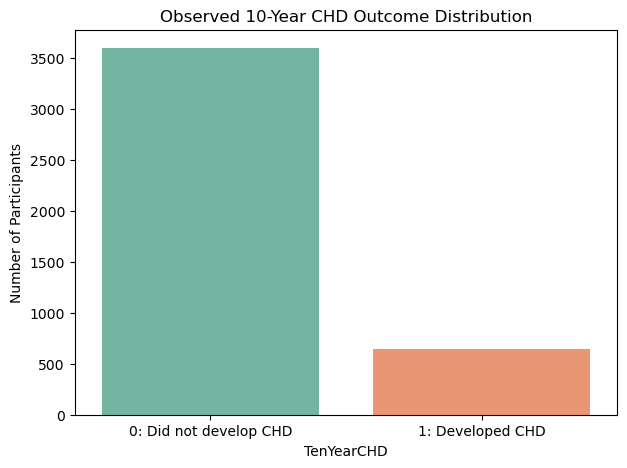

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x='TenYearCHD',
    hue='TenYearCHD',
    palette='Set2',
    legend=False
)

plt.title("Observed 10-Year CHD Outcome Distribution")
plt.xlabel("TenYearCHD")
plt.ylabel("Number of Participants")
plt.xticks(
    ticks=[0, 1],
    labels=["0: Did not develop CHD", "1: Developed CHD"]
)

plt.show()



 Approximately 3,600 participants belonged to the non-CHD group, whereas only about 640 participants developed CHD.

# =========================
# 4. AGE DISTRIBUTION BY CHD OUTCOME
# =========================


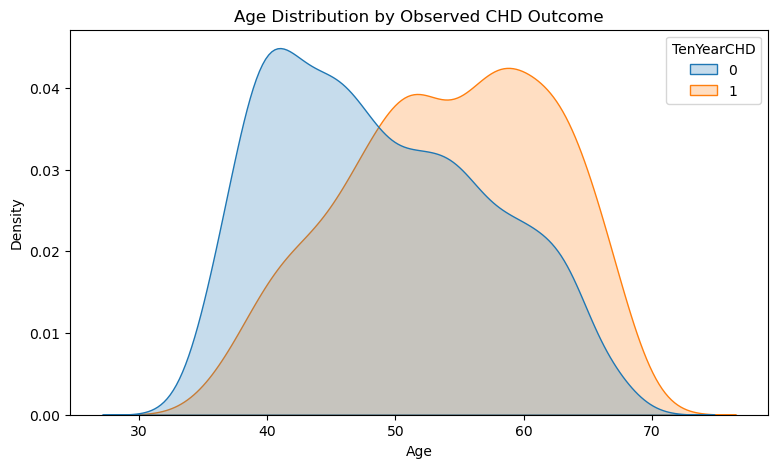

In [ ]:
plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=df_clean,
    x='age',
    hue='TenYearCHD',
    fill=True,
    common_norm=False
)

plt.title("Age Distribution by Observed CHD Outcome")
plt.xlabel("Age")
plt.ylabel("Density")

plt.show()





# =========================
# 5. OBSERVED CHD RATE BY AGE GROUP
# =========================

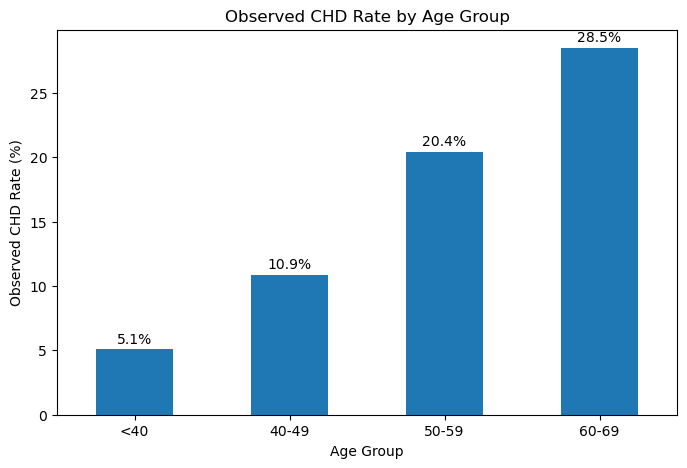

In [ ]:
df_clean['AgeGroup'] = pd.cut(
    df_clean['age'],
    bins=[0, 40, 50, 60, 70, 100],
    labels=['<40', '40-49', '50-59', '60-69', '70+']
)

age_chd_rate = df_clean.groupby('AgeGroup', observed=True)['TenYearCHD'].mean() * 100

plt.figure(figsize=(8, 5))
ax = age_chd_rate.plot(kind='bar')

plt.title("Observed CHD Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Observed CHD Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(age_chd_rate):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.show()


This graph shows the percentage of participants who developed coronary heart disease (CHD) within 10 years across different age groups.

CHD risk increased proportionally with age, rising from 5.1% in participants younger than 40 years to 28.5% in participants aged 60–69 years.
This means that the oldest age group experienced more than five times the CHD rate observed in the youngest age group.  

<br>

**Limitation**  
- This graph shows an association rather than a causal relationship. Older participants may also have higher blood pressure, diabetes prevalence, cholesterol levels, or other cardiovascular risk factors that contribute to the increased CHD rates. In particular, hypertension prevalence increased substantially across age groups, suggesting that part of the observed relationship between age and CHD may be explained by age-related increases in blood pressure.  
- Future analyses could investigate whether age directly influences CHD risk or whether its effect is partially mediated through other age-related conditions such as hypertension, diabetes, and elevated cholesterol levels.  
Isolating these variables would allow a better assessment of their independent contributions to CHD outcomes.


# =========================
# 6. OBSERVED CHD RATE BY SMOKING INTENSITY
# =========================

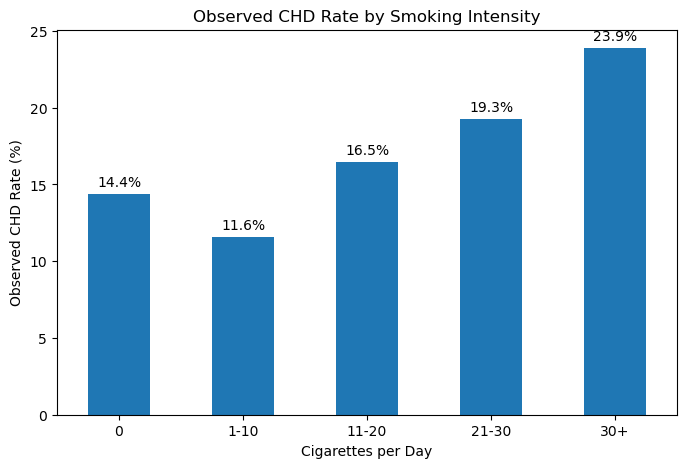

In [ ]:
df_clean['SmokingGroup'] = pd.cut(
    df_clean['cigsPerDay'],
    bins=[-1, 0, 10, 20, 30, 100],
    labels=['0', '1-10', '11-20', '21-30', '30+']
)

smoking_chd_rate = df_clean.groupby('SmokingGroup', observed=True)['TenYearCHD'].mean() * 100

plt.figure(figsize=(8, 5))
ax = smoking_chd_rate.plot(kind='bar')

plt.title("Observed CHD Rate by Smoking Intensity")
plt.xlabel("Cigarettes per Day")
plt.ylabel("Observed CHD Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(smoking_chd_rate):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.show()

# OBSERVED CHD RATE BY SMOKING INTENSITY
This graph shows the percentage of participants who developed coronary heart disease (CHD) within 10 years across different smoking intensity groups.

Participants who smoked more cigarettes per day generally experienced higher CHD rates.
The highest smoking group (30+ cigarettes per day) showed the highest CHD rate at 23.9%, compared with 14.4% among non-smokers.

<br>

**Limitation**  
This analysis is based on observed group averages and does not control for other cardiovascular risk factors.
- Non-smokers = 14.4%
- 1–10 smokers = 11.6%

However, the relationship is not perfectly monotonic because the 1–10 cigarettes per day group (11.6%) had a slightly lower CHD rate than non-smokers (14.4%). This may be due to confounding factors such as age, blood pressure, diabetes status, or differences in the composition of the smoking groups. For example, non-smokers may be older on average or have higher blood pressure. Since this graph does not adjust for confounding variables, small inconsistencies can occur even when the overall trend suggests increased CHD risk with heavier smoking.

# =========================
# 7. OBSERVED CHD RATE BY SYSTOLIC BLOOD PRESSURE
# =========================


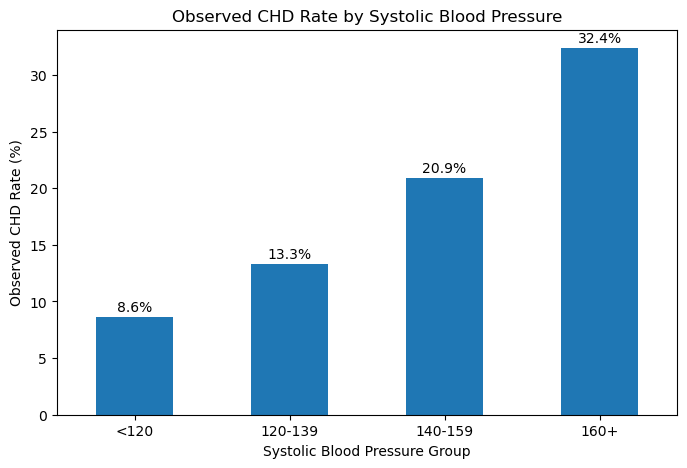

In [ ]:
df_clean['SysBPGroup'] = pd.cut(
    df_clean['sysBP'],
    bins=[0, 120, 140, 160, 300],
    labels=['<120', '120-139', '140-159', '160+']
)

sysbp_chd_rate = df_clean.groupby('SysBPGroup', observed=True)['TenYearCHD'].mean() * 100

plt.figure(figsize=(8, 5))
ax = sysbp_chd_rate.plot(kind='bar')

plt.title("Observed CHD Rate by Systolic Blood Pressure")
plt.xlabel("Systolic Blood Pressure Group")
plt.ylabel("Observed CHD Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(sysbp_chd_rate):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.show()


The graph displays the observed percentage of participants who developed CHD within 10 years in different systolic blood pressure (SysBP) categories.

As systolic blood pressure increases, the proportion of participants who developed CHD also increases.

For example:

- Participants with systolic blood pressure below 120 mmHg had a CHD rate of only 8.6%.
- Participants with systolic blood pressure above 160 mmHg had a CHD rate of 32.4%.

This means the highest blood pressure group experienced almost four times the CHD rate of the lowest blood pressure group.

# =========================
# 8. CORRELATION MATRIX
# =========================

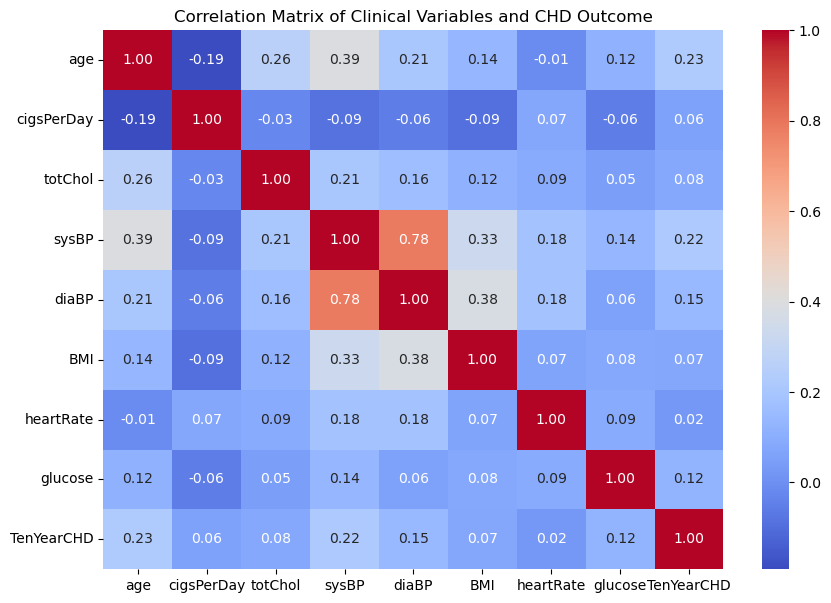

In [ ]:
selected_cols = [
    'age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP',
    'BMI', 'heartRate', 'glucose', 'TenYearCHD'
]

corr = df_clean[selected_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix of Clinical Variables and CHD Outcome")

plt.show()

# **Correlation Matrix Of Clinical Variables and CHD Outcome**
- +1.00  = perfect positive relationship
- 0.00  = no linear relationship
- -1.00  = perfect negative relationship

<br>

**sysBP ↔ diaBP = 0.78**  
The strongest correlation in the dataset was observed between systolic and diastolic blood pressure (r = 0.78), indicating a strong positive relationship between the two blood pressure measures.Participants with higher systolic blood pressure tend to also have higher diastolic blood pressure.

Age is related to blood pressure.
- age ↔ sysBP = 0.39
- age ↔ diaBP = 0.21
Older participants tended to have higher blood pressure.

BMI is related to blood pressure.
- BMI ↔ diaBP = 0.38
- BMI ↔ sysBP = 0.33
Higher BMI was associated with higher blood pressure levels.

Correlation with CHD outcome
- age     = 0.23
- sysBP   = 0.22
Age and systolic blood pressure showed the strongest positive correlations with CHD occurrence in this subset of variables.

Why are the CHD correlations so small?  
Because CHD is binary and heart disease is multifactoral.No single variable perfectly predicts CHD.

The correlation matrix revealed that systolic and diastolic blood pressure were strongly correlated (r = 0.78). Age showed moderate positive correlations with blood pressure and the strongest correlation with CHD outcome (r = 0.23).  
Systolic blood pressure was also positively associated with CHD occurrence (r = 0.22). Most other variables showed weak correlations with CHD, suggesting that coronary heart disease is influenced by multiple interacting risk factors rather than a single dominant variable.

In [ ]:

features = [
    'male', 'age', 'education', 'currentSmoker', 'cigsPerDay',
    'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes',
    'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]

X = df_clean[features]
y = df_clean['TenYearCHD']

model = LogisticRegression(max_iter=5000)
model.fit(X, y)

print("Model fitted successfully.")

Model fitted successfully.


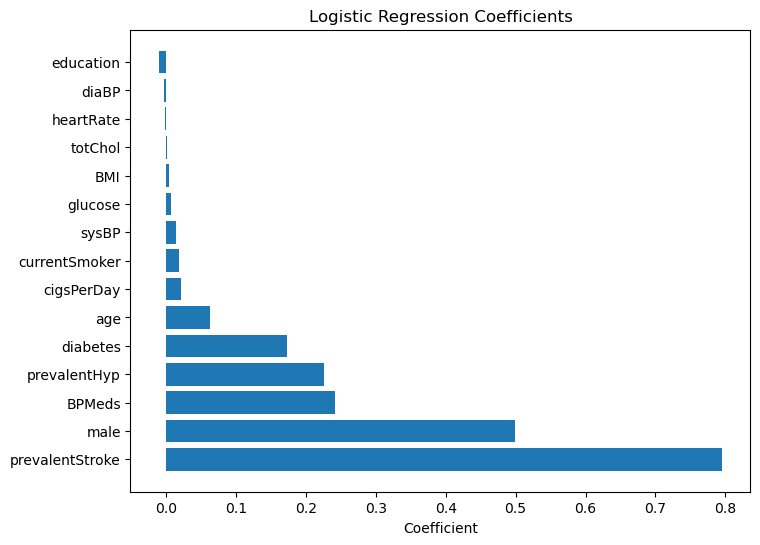

In [ ]:
coef = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

coef = coef.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(coef['Variable'], coef['Coefficient'])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.show()

# Which variables did the logistic regression model find most useful for predicting CHD?
- The logistic regression model identified previous stroke, male sex, hypertension-related variables, and diabetes as the strongest predictors of 10-year CHD occurrence. Smoking-related variables and age also contributed positively to prediction, although with smaller coefficients.

AgeGroup
<40      0.133690
40-49    0.186451
50-59    1.073620
60-69    1.208981
Name: prevalentStroke, dtype: float64


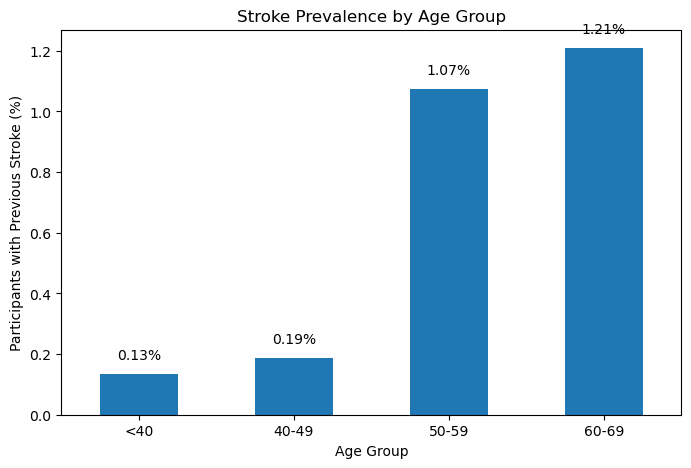

In [ ]:
# Does stroke become more common with age?

stroke_by_age = (
    df_clean
    .groupby('AgeGroup', observed=True)['prevalentStroke']
    .mean()
    * 100
)

print(stroke_by_age)

ax = stroke_by_age.plot(kind='bar', figsize=(8,5))

plt.title("Stroke Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Participants with Previous Stroke (%)")
plt.xticks(rotation=0)

for i, value in enumerate(stroke_by_age):
    ax.text(i, value + 0.05, f"{value:.2f}%", ha='center')

plt.show()

The prevalence of previous stroke increased with age, rising from 0.13% among participants younger than 40 years to 1.21% among participants aged 60–69 years. Although stroke became more common in older age groups, its overall prevalence remained very low throughout the dataset also because in the first cohort only resident without a stroke were chosen.

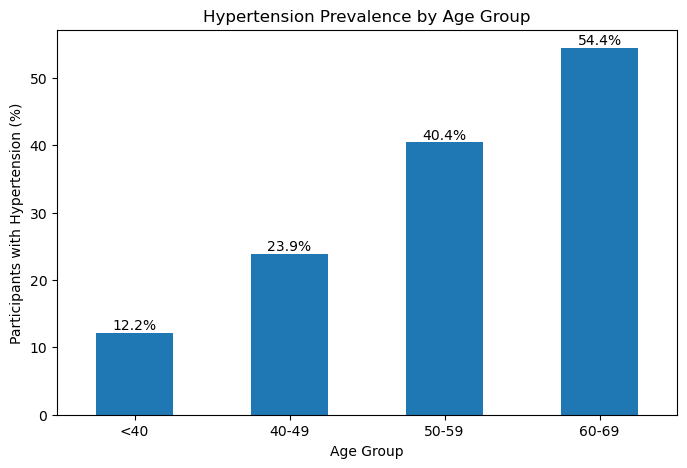

In [ ]:
# Hypertension by age

hyp_by_age = (
    df_clean
    .groupby('AgeGroup', observed=True)['prevalentHyp']
    .mean()
    * 100
)

ax = hyp_by_age.plot(kind='bar', figsize=(8,5))

plt.title("Hypertension Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Participants with Hypertension (%)")
plt.xticks(rotation=0)

for i, value in enumerate(hyp_by_age):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.show()

This graph shows the percentage of participants with hypertension (prevalentHyp = 1) across different age groups.
Hypertension prevalence increased steadily with age, affecting more than half of participants aged 60–69 years.

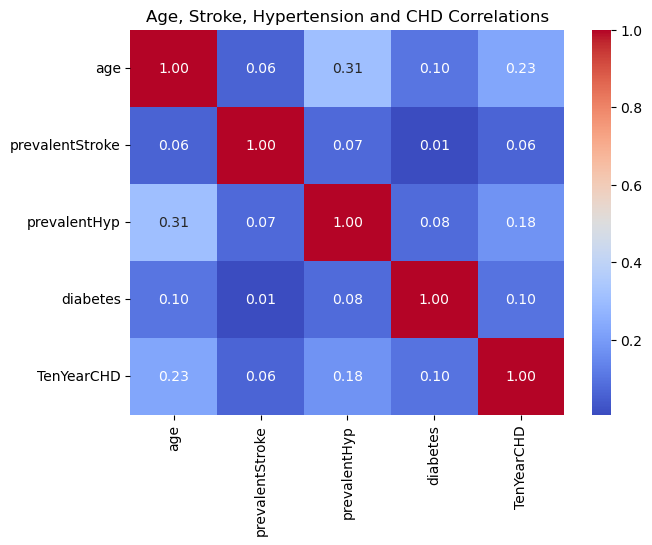

In [ ]:
selected = [
    'age',
    'prevalentStroke',
    'prevalentHyp',
    'diabetes',
    'TenYearCHD'
]

plt.figure(figsize=(7,5))

sns.heatmap(
    df_clean[selected].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Age, Stroke, Hypertension and CHD Correlations")
plt.show()

# **Stroke => CHD not Stroke <=> CHD**

Age looks extremely important in the age graph, but logistic regression says prevalentStroke is the most important variable.
The logistic coefficient graph might be misleading here.

What our logistic regression is saying is:

- When we encounter one of those rare people with a previous stroke, their CHD risk is much higher.

That gives stroke a large coefficient.  
But that is not the same as saying stroke is the most important population-level risk factor.


99% of people → no stroke
1% of people → previous stroke

But among that 1%, CHD risk is very high.

Therefore:

- Stroke gets a large coefficient.
- Age affects many more participants overall.

Although previous stroke received the largest coefficient in the logistic regression model, stroke was relatively rare in the dataset and showed only a weak overall correlation with CHD (r = 0.06) (also due to first cohort being people with no previous CHD history). In contrast, age demonstrated a much stronger association with CHD occurrence (r = 0.23), and CHD rates increased substantially across age groups. Therefore, age appears to be one of the most important population-level risk factors, while previous stroke represents a strong but uncommon high-risk condition.

# Potential Use Cases

- **Targeted Public Health Strategies (Two-Track Approach)**:
  Our analysis shows a clear distinction between widespread risks and rare, extreme risks. Healthcare organizations can use these insights to design a two-track strategy: launching mass campaigns for age-appropriate lifestyle changes (since age affects the whole population), while creating separate, intensive care programs specifically for the small 1% of stroke survivors who face extreme individual risk.

- **Improved Clinical Screening Guidelines**:
  Medical practitioners can use our findings about risk factor distributions to improve patient screening checklists. Even if a patient is young and appears safe according to population averages, a history of a previous stroke should immediately trigger a high-priority warning, as our analysis confirms its massive statistical weight for an individual's risk.

- **Epidemiological Research on Study Design Bias**:
  Our discovery regarding the scarcity of stroke patients (less than 1%) highlights how study entry criteria can reshape data. Researchers can use this case as a prime example of how filtering out baseline heart disease patients naturally filters out related vascular conditions, teaching future epidemiologists how to correctly interpret hidden biases in historical medical data.

- **Optimizing Medical Resource Allocation**:
  Hospital administrators and governments can allocate limited medical budgets more efficiently based on these statistical patterns. They can invest the majority of resources into widespread screening for older age groups (high population impact) while setting aside specialized medical teams and equipment for the small, critical percentage of patients with complex vascular histories (high individual impact).

# Limitations and Challenges

- Missing Data

Several variables contained missing values, particularly glucose, education, and BPMeds. Although median and mode imputation were used, imputed values may not perfectly represent the original observations.

- Loss of Temporal Dynamics due to Cross-Sectional Simplification  

This dataset only represents a static, single-wave snapshot from the baseline examination. It fails to capture individual health trajectories or changes in clinical metrics (such as blood pressure or smoking habits) that naturally occur over a 10-year period.

- Skewed Target Distribution (Class Imbalance)

The target variable (`TenYearCHD`) is highly unbalanced, only 15% cardiovascular patients. It difficult to compare the two groups equally and can easily obscure the distinct clinical patterns of the high-risk minority.

- Lack of Demographic and Historical Diversity  

The sample population is restricted to a single, ethnically homogenous cohort (mostly white, middle-class residents) from the mid-20th century.The dietary habits, lifestyles, and healthcare standards of that specific era differ from modern times, which limits the generalizability of our findings to diverse, modern global populations. Therefore, results may not fully generalize to all populations worldwide.

- Confounding Variables

Many cardiovascular risk factors are interrelated.

For example:

- Age → Hypertension → CHD
- Age → Diabetes → CHD

As a result, it is difficult to isolate the independent effect of individual variables.

- Correlation Does Not Imply Causation

Although variables such as age, smoking, and blood pressure were associated with CHD, these analyses alone cannot prove that they directly caused the observed outcomes.

# Summary
The Framingham dataset provides clear evidence that personal details, daily habits, and health measurements are closely linked to heart disease. While factors like older age, high blood pressure, and smoking obviously increase the risk of heart problems, our analysis highlights a critical distinction between an individual's risk and the risk at a population level.

For example, our data analysis shows that having a previous stroke (`prevalentStroke`) is an incredibly dangerous warning sign for a single patient, meaning that individuals in this tiny group have a very high rate of heart disease. However, having a stroke is extremely rare in this dataset, appearing in less than 1% of the participants. This scarcity happened because the study strictly excluded anyone who already had heart disease at the start. Since stroke and heart disease share the same vascular causes, most stroke patients were filtered out during this recruitment process.

In contrast, a common factor like age affects every participant in the group and shows a much stronger overall correlation ($r = 0.23$) to heart disease. Therefore, we conclude that while a previous stroke is a powerful but uncommon condition for a few individuals, age serves as one of the most significant and widespread risk factors for the general population.

# References
 - ChatGPT
 - ClaudeAI
 - https://en.wikipedia.org/wiki/Framingham_Heart_Study
 - https://en.wikipedia.org/wiki/Framingham_Risk_Score